# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, weibull_min, genextreme, kstest
from dataclasses import dataclass

# 1. Input Parameters
collects all fixed inputs (material, geometry, loading, AM process)

## 1.1 Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [2]:
C = 1.0e-11     # Paris pre-factor  [m/cycle / (MPa√m)^m]  — Ti-6Al-4V LPBF (literature)
m = 3.2         # Paris exponent    [–]

K_c  = 60.0     # fracture toughness      [MPa√m]
K_th = 3.0      # threshold SIF range     [MPa√m]
E    = 114.0    # Young's modulus         [GPa]

print(f"Paris law:  da/dN = {C:.2e} · deltaK^{m}")
print(f"K_c = {K_c} MPa√m,  K_th = {K_th} MPa√m,  E = {E} GPa")

Paris law:  da/dN = 1.00e-11 · deltaK^3.2
K_c = 60.0 MPa√m,  K_th = 3.0 MPa√m,  E = 114.0 GPa


## 1.2 Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [3]:
w = 5e-3        # cross-section width   [m]
h_s = 5e-3      # cross-section height  [m]
L = 20e-3       # gauge length          [m]

V_gauge = w * h_s * L          # gauge volume  [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3]  for display

# Geometry correction factor Y (Murakami framework)
#   Y = 0.5 for internal defect
#   Y = 0.6 for surface defect
defect_location = "internal"
Y = 0.5 if defect_location == "internal" else 0.6

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")
print(f"Defect location: {defect_location} → Y = {Y}")

Gauge volume V = 500.0 mm^3
Defect location: internal → Y = 0.5


## 1.3 Loading Parameters
stress amplitude, mean stress, frequency

In [4]:
sigma_a = 200.0     # stress amplitude  [MPa]
sigma_m = 0.0       # mean stress       [MPa]  (0 → fully reversed, R = -1)
freq    = 20.0      # cyclic frequency  [Hz]

sigma_max = sigma_m + sigma_a
sigma_min = sigma_m - sigma_a
R = sigma_min / sigma_max if sigma_max != 0 else float("nan")

# Effective stress range: crack faces close under compression, no damage contribution
delta_sigma = sigma_max - max(sigma_min, 0.0)   # deltaK = Y·delta_sigma·√(pia)

print(f"sigma_a = {sigma_a} MPa, sigma_m = {sigma_m} MPa")
print(f"sigma_max = {sigma_max:.1f}, sigma_min = {sigma_min:.1f}, R = {R:.2f}")
print(f"Effective delta_sigma = {delta_sigma:.1f} MPa")

sigma_a = 200.0 MPa, sigma_m = 0.0 MPa
sigma_max = 200.0, sigma_min = -200.0, R = -1.00
Effective delta_sigma = 200.0 MPa


## 1.4 AM Process Parameters & Volumetric Energy Density
laser power, scan speed, hatch spacing, layer thickness

**VED = P / (v · h · t)**

- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

In [5]:
P   = 200.0     # laser power       [W]
v   = 1200.0    # scan speed        [mm/s]
h   = 0.11      # hatch spacing     [mm]
t   = 0.03      # layer thickness   [mm]

VED = P / (v * h * t)   # eq. (1)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED = {VED:.2f} J/mm^3")

P = 200.0 W,  v = 1200.0 mm/s,  h = 0.11 mm,  t = 0.03 mm
VED = 50.51 J/mm^3


# 2. Volume, Defect Density, and PDF
- Volumetric Energy Density (VED) from AM process parameters
- Defect number density rho_def from XCT data
- Expected defect count in the gauge volume
- Parametric PDF fit to measured defect sizes

## 2.1 Defect Number Density
**Replace the placeholder values below with real XCT data!**

**rho_def = N_def / V_scan**

Expected defects in gauge volume:  **⟨N⟩ = rho_def · V**

In [ ]:
# ── PLACEHOLDER: replace with real values ──────────────────────────────
N_def_xct   = 240           # defects detected in scanned volume
V_scan_mm3  = 1500.0        # scanned volume  [mm^3]
# ───────────────────────────────────────────────────────────────────────────

V_scan = V_scan_mm3 * 1e-9  # convert to m^3

rho_def = N_def_xct / V_scan          # defect number density  [m⁻^3]
N_expected = rho_def * V_gauge        # expected defects in gauge volume

print(f"Scanned volume, V_scan = {V_scan_mm3:.1f} mm^3")
print(f"Detected defects, N_def = {N_def_xct}")
print(f"Defect density, rho_def = {rho_def:.4e} m⁻^3")
print(f"Gauge volume, V = {V_gauge_mm3:.1f} mm^3")
print(f"Expected defects, ⟨N⟩ = {N_expected:.1f}")

Scanned volume, V_scan = 1500.0 mm^3
Detected defects, N_def = 240
Defect density, rho_def = 1.6000e+08 m⁻^3
Gauge volume, V = 500.0 mm^3
Expected defects, ⟨N⟩ = 80.0


## 2.2 VED–Defect Density Correlation
A U-shaped empirical curve relates VED to defect density:
both under- and over-melting increase porosity.

**Replace VED_opt, rho_min, alpha with fitted values!**

In [7]:
def defect_density_from_VED(VED, VED_opt=80.0, rho_min=50.0, alpha=0.08):
    """
    Correlation:  rho(VED) = rho_min + alpha·(VED - VED_opt)^2
    
    Parameters
    ----------
    VED     : float  — volumetric energy density  [J/mm^3]
    VED_opt : float  — optimal VED (minimum defect density)
    rho_min : float  — minimum defect density at VED_opt  [defects/mm^3]
    alpha   : float  — curvature coefficient
    
    Returns
    -------
    rho : float — defect density  [defects/mm^3]
    """
    return rho_min + alpha * (VED - VED_opt) ** 2

In [8]:
VED_sweep = np.linspace(20, 200, 300)           # VED range for sweep [J/mm^3]
rho_sweep = defect_density_from_VED(VED_sweep)  # corresponding defect densities
rho_this  = defect_density_from_VED(VED)        # defect density at operating VED

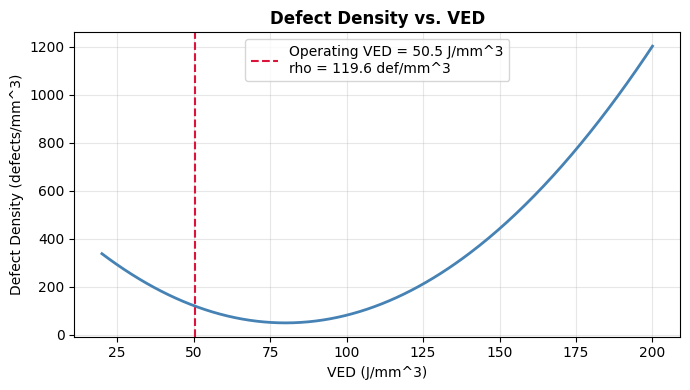

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(VED_sweep, rho_sweep, color="steelblue", linewidth=2)
ax.axvline(VED, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Operating VED = {VED:.1f} J/mm^3\nrho = {rho_this:.1f} def/mm^3")

# axes labels, title, legend, grid
ax.set_title("Defect Density vs. VED", fontweight="bold")
ax.set_xlabel("VED (J/mm^3)")
ax.set_ylabel("Defect Density (defects/mm^3)")

# legend, grid
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/2_VED_rho.png", dpi=150)
plt.show()

## 2.3 Defect Size Distribution Parameters from VED
**Replace the placeholder quadratic models below with real fits!**

Empirical correlations between VED and the lognormal PDF parameters (mu_ln, sigma_ln) are calibrated from a process-window XCT campaign.

In [10]:
# define function for the mean of ln(defect size) as a function of VED
def defect_mu_ln(VED, VED_opt=80.0):
    """
    Mean of ln(defect size): mu_ln(VED) = mu_0 + B·(VED - VED_opt)^2
    Units: ln(m), tuned so exp(mu_ln) ≈ 50 micrometers at VED_opt
    Replace coefficients with those from XCT campaign.
    """
    mu_0 = np.log(50e-6)    # ln(50 micrometers) at optimal VED
    beta = 2e-6             # sensitivity to VED deviation  [ln(m) / (J/mm^3)^2]
    return mu_0 + beta * (VED - VED_opt)**2

# define function for the std dev of ln(defect size) as a function of VED
def defect_sigma_ln(VED):
    # assumed constant; replace if data shows VED-dependent spread
    return 0.45

mu_ln = defect_mu_ln(VED)
sigma_ln = defect_sigma_ln(VED)

print(f"Lognormal parameters at VED = {VED:.1f} J/mm^3:")
print(f"  mu_ln = {mu_ln:.4f} → median defect = {np.exp(mu_ln)*1e6:.1f} micrometers")
print(f"  sigma_ln = {sigma_ln:.4f}")

Lognormal parameters at VED = 50.5 J/mm^3:
  mu_ln = -9.9017 → median defect = 50.1 micrometers
  sigma_ln = 0.4500


## 2.4 Generate Synthetic Defect Population
**Replace the placeholder below with real XCT defect-size array!**

In [11]:
# ── PLACEHOLDER: replace with defect_sizes = <XCT array in metres> ──
rng = np.random.default_rng(42)
n_xct = 150     # number of defects detected across all scanned specimens

defect_sizes = rng.lognormal(mean=mu_ln, sigma=sigma_ln, size=n_xct)  # [m]
# ───────────────────────────────────────────────────────────────────────────

print(f"Defect population: n = {len(defect_sizes)}")
print(f"  min = {defect_sizes.min()*1e6:.1f} micrometers")
print(f"  mean = {defect_sizes.mean()*1e6:.1f} micrometers")
print(f"  max = {defect_sizes.max()*1e6:.1f} micrometers")

Defect population: n = 150
  min = 19.2 micrometers
  mean = 52.8 micrometers
  max = 185.9 micrometers


## 2.5 Fit Parametric PDF: MLE & KS Goodness-of-Fit
Three candidate distributions are fitted by MLE.

The best is selected by the lowest Kolmogorov–Smirnov statistic.

In [12]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [13]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(defect_sizes, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name}  (KS = {best_ks:.4f},  p = {best_p:.4f})")

param_str = ",  ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.0444      0.9155
Weibull               0.0920      0.1485
Gumbel                0.0485      0.8549

Best fit: lognormal  (KS = 0.0444,  p = 0.9155)
Parameters: mu_ln = -9.925,  sigma_ln = 0.3838


## 2.6 Defect Size Histogram & Best-Fit PDF

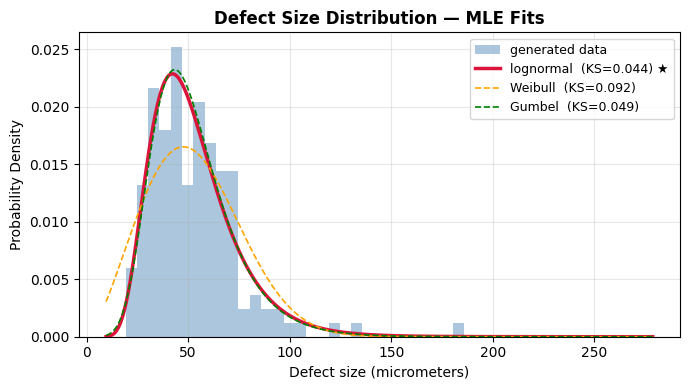

In [14]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = defect_sizes * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(defect_sizes.min() * 0.5, defect_sizes.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution — MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_defect_pdf.png", dpi=150)
plt.show()

## 2.7 GEV Fit to √Area (Max-Defect Distribution)
Each specimen contains many defects.

Fatigue failure is controlled by the **largest** defect (Murakami).

The distribution of per-specimen maxima follows a Generalized Extreme Value (GEV) distribution.

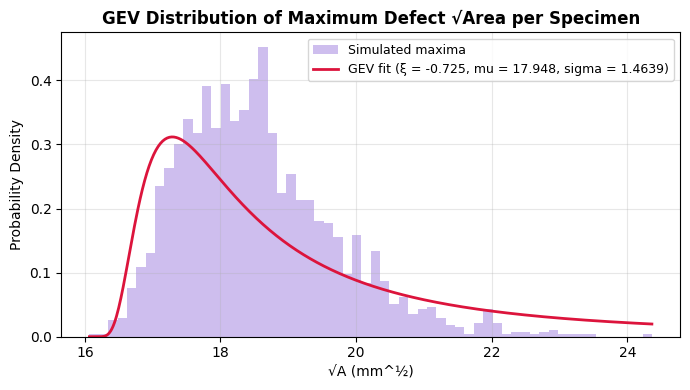

In [15]:
# Simulate per-specimen maximum defects over many virtual specimens
n_specimens = 2000
rho_mm3 = rho_this          # defects/mm^3 at operating VED
V_spec_mm3 = V_gauge_mm3    # gauge volume in mm^3

max_defects = []
for _ in range(n_specimens):
    n_local = np.random.poisson(rho_mm3 * V_spec_mm3)
    n_local = max(n_local, 1)

    # use lognormal since best fit; replace with best-fitting distribution if different
    specimen_defects = rng.lognormal(mean=mu_ln, sigma=sigma_ln, size=n_local)
    max_defects.append(specimen_defects.max())

max_defects = np.array(max_defects)
sqrt_A = np.sqrt(max_defects)       # Murakami √area parameter  [√m]

# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A)
x_gev = np.linspace(sqrt_A.min(), sqrt_A.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sqrt_A * 1e3, bins=60, density=True, alpha=0.45,
        color="mediumpurple", label="Simulated maxima")

# scale pdf axis to mm^(1/2) for display
ax.plot(x_gev * 1e3,
        pdf_gev / 1e3,      # Jacobian: dx_m^0.5 = dx_mm^0.5 / 1e3
        color="crimson", linewidth=2,
        label=f"GEV fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_GEV.png", dpi=150)
plt.show()

## 2.8 Paris-Law Fatigue Life: Formulae
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [16]:
# define a function to compute fatigue life from Paris law and Shiozawa approx.
def paris_Nf(a_i, sigma_a, C, m, Y, delta_sigma=None):
    """
    N_f ≈ 2 / [(m-2)·C·(Y·delta_sigma)^m·pi^(m/2)] · a_i^(1 - m/2)

    Parameters
    ----------
    a_i       : float or array  — initial crack size [m]
    sigma_a   : float           — stress amplitude [MPa]  (used if delta_sigma=None)
    C, m      : Paris constants
    Y         : geometry factor
    delta_sigma: float, optional — override stress range (for R ≠ -1 cases)

    Returns
    -------
    N_f : float or array  — fatigue life  [cycles]
    """
    
    if delta_sigma is None:
        # fully reversed (R = -1): delta_sigma = 2·sigma_a
        delta_sigma = 2.0 * sigma_a

    prefactor = 2.0 / ((m - 2) * C * (Y * delta_sigma)**m * np.pi**(m / 2)) # constant of Paris/Shiozawa equation
    
    return prefactor * a_i**(1.0 - m / 2.0)

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    # deltaK_i = Y·delta_sigma·√(pi·a_i)  [MPa√m]
    return Y * delta_sigma * np.sqrt(np.pi * a_i)

In [17]:
# check
a_example = 50e-6       # 50 micrometers defect
Nf_example = paris_Nf(a_example, sigma_a, C, m, Y)
dK_example = delta_K_initial(a_example, delta_sigma, Y)

print(f"Example: a_i = {a_example*1e6:.0f} micrometers")
print(f"  deltaK_i = {dK_example:.3f} MPa√m")
print(f"  N_f = {Nf_example:.3e} cycles")

Example: a_i = 50 micrometers
  deltaK_i = 1.253 MPa√m
  N_f = 4.403e+05 cycles


## 2.9 Monte Carlo: Fatigue Life Distribution at Fixed Stress

Each virtual specimen gets a random critical (max.) defect drawn from the fitted PDF.

Paris law + Shiozawa gives N_f for each specimen.

The resulting distribution captures the scatter from defect variability alone.

In [18]:
S_fixed = sigma_a   # [MPa]
M_mc = 5000         # number of Monte Carlo specimens

# take critical defect sizes from the best-fit PDF
a0_samples = best_frozen.rvs(size=M_mc, random_state=rng)       # [m]
a0_samples = np.clip(a0_samples, 1e-9, None)                    # prevent zeros

# compute fatigue life, deltaK_i, and Murakami √area for each specimen
Nf_samples   = paris_Nf(a0_samples, S_fixed, C, m, Y)
dKi_samples  = delta_K_initial(a0_samples, delta_sigma, Y)
sqrtA_mc     = np.sqrt(a0_samples)          # Murakami parameter √A  [√m]
Nnorm_samples = Nf_samples / sqrtA_mc       # normalized life  N/√A

print(f"Monte Carlo, (M = {M_mc}, S = {S_fixed} MPa)")
print(f"  N_f — mean = {Nf_samples.mean():.3e}, std = {Nf_samples.std():.3e}")
print(f"  deltaK_i - mean = {dKi_samples.mean():.3f} MPa√m")

Monte Carlo, (M = 5000, S = 200.0 MPa)
  N_f — mean = 4.583e+05, std = 1.057e+05
  deltaK_i - mean = 1.261 MPa√m


### 2.9.a Fatigue Life Histogram

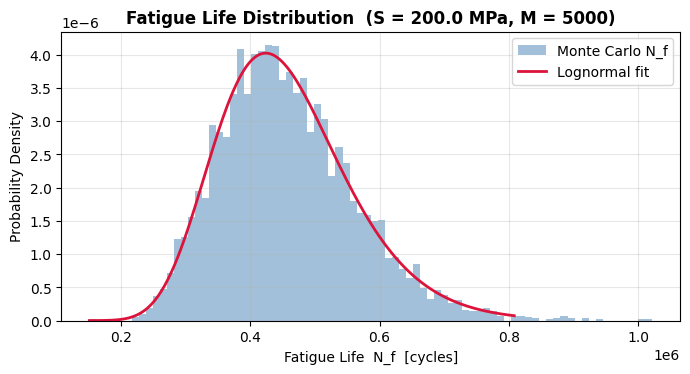

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(Nf_samples, bins=80, density=True, alpha=0.5,
        color="steelblue", label="Monte Carlo N_f")

# overlay lognormal fit to the fatigue life distribution
s_nf, _, scale_nf = lognorm.fit(Nf_samples, floc=0)
x_nf = np.linspace(Nf_samples.min(), np.percentile(Nf_samples, 99.5), 400)
ax.plot(x_nf, lognorm.pdf(x_nf, s_nf, 0, scale_nf),
        color="crimson", linewidth=2, label="Lognormal fit")

# axes labels, title
ax.set_title(f"Fatigue Life Distribution  (S = {S_fixed} MPa, M = {M_mc})",
             fontweight="bold")
ax.set_xlabel("Fatigue Life  N_f  [cycles]")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend()
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_Nf_histogram.png", dpi=150)
plt.show()

### 2.9.b Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:

deltaK_i ∝ (N/√A)^(1/(2-m)) → **slope = 1/(2-m)**

Shiozawa log-log fit: slope = -0.4545
Expected from Paris (m=3.2): slope = -0.8333


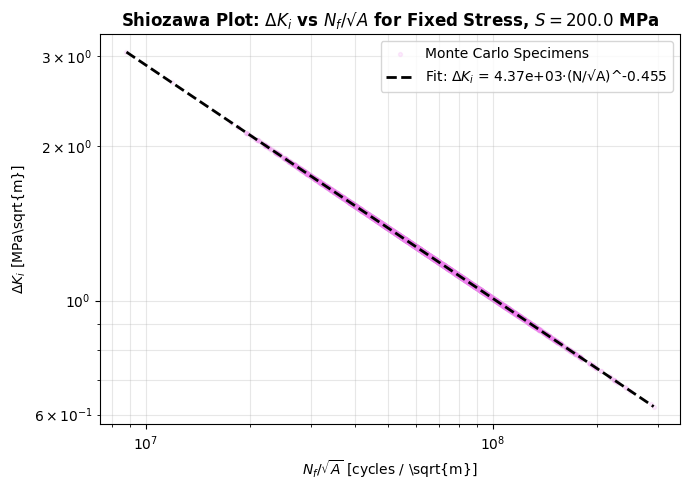

In [20]:
# log-log linear fit
log_Nnorm  = np.log10(Nnorm_samples)
log_dKi    = np.log10(dKi_samples)

# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = 1.0 / (2.0 - m)
print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

N_norm_line = np.logspace(np.log10(Nnorm_samples.min()),
                           np.log10(Nnorm_samples.max()), 300)
dK_line = a_fit * N_norm_line**slope

# plot Shiozawa plot
fig, ax = plt.subplots(figsize=(7, 5))
# show Monte Carlo specimens as scatter points
ax.scatter(Nnorm_samples, dKi_samples, alpha=0.15, s=8, color="violet",
           label="Monte Carlo Specimens")
# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="black", linewidth=2, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}·(N/√A)^{slope:.3f}")

# log-log scale for Shiozawa plot
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_title(f"Shiozawa Plot: $\\Delta K_i$ vs $N_f / √A$ for Fixed Stress, $S = {S_fixed}$ MPa",
             fontweight="bold")
ax.set_xlabel("$N_f / \\sqrt{A}$ [cycles / \\sqrt{m}]")
ax.set_ylabel("$\\Delta K_i$ [MPa\\sqrt{m}]")

# legend, grid
ax.legend()
ax.grid(alpha=0.3, which="both")

# save and show
plt.tight_layout()
plt.savefig("graphs/2_shiozawa.png", dpi=150)
plt.show()

### 2.9.c Reliability Curves: Empirical & Weibull Model

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison.

Weibull: β = 4.396, η = 5.004e+05
  B10 (10% failure) = 2.999e+05 cycles
  B50 (50% failure) = 4.604e+05 cycles


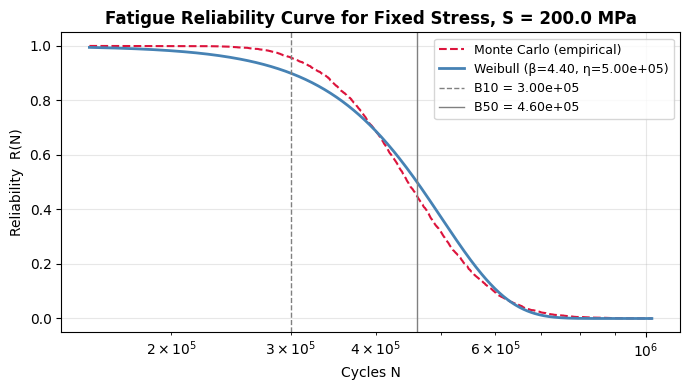

In [21]:
lives_sorted = np.sort(Nf_samples)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Monte Carlo (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")
# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Fatigue Reliability Curve for Fixed Stress, S = {S_fixed} MPa",
             fontweight="bold")
ax.set_xlabel("Cycles N")
ax.set_ylabel("Reliability  R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_reliability.png", dpi=150)
plt.show()

## 2.10 Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

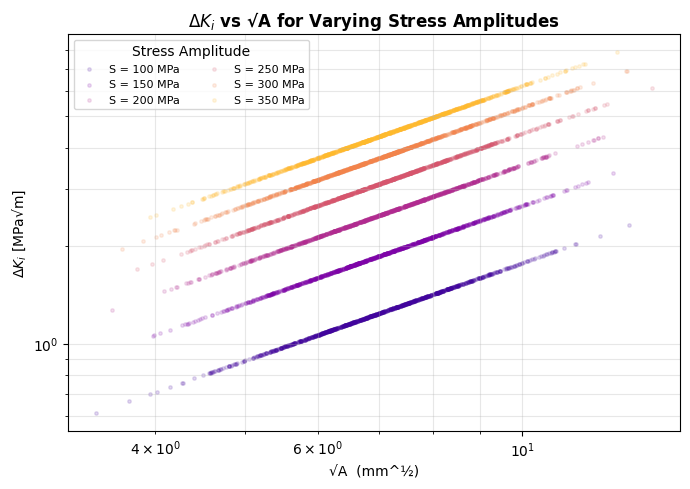

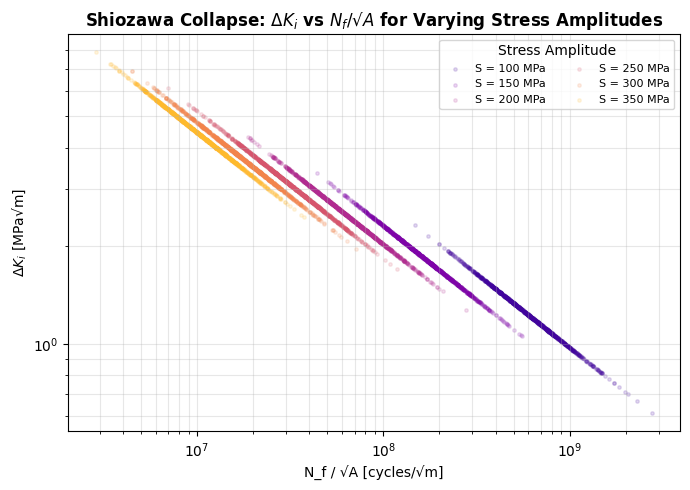

In [22]:
S_vals = [100, 150, 200, 250, 300, 350]     # stress amplitudes to sweep [MPa]
M_per_S = 1000                              # Monte Carlo specimens per stress level

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    a0_i = best_frozen.rvs(size=M_per_S, random_state=rng)
    a0_i = np.clip(a0_i, 1e-9, None)

    ds_i   = 2.0 * Si                       # delta_sigma for R = -1
    Nf_i   = paris_Nf(a0_i, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i  = delta_K_initial(a0_i, ds_i, Y)
    sqA_i  = np.sqrt(a0_i)
    Nn_i   = Nf_i / sqA_i

    ax1.scatter(sqA_i * 1e3, dKi_i, alpha=0.15, s=6, color=ci,
                label=f"S = {Si} MPa")
    ax2.scatter(Nn_i, dKi_i, alpha=0.15, s=6, color=ci,
                label=f"S = {Si} MPa")

for ax, xlabel, title in [
    (ax1, "√A  (mm^½)", "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    #deltaK_i vs √A for Varying Stress Amplitudes"),
    (ax2, "N_f / √A [cycles/√m]", "Shiozawa Collapse: $\\Delta K_i$ vs $N_f / √A$ for Varying Stress Amplitudes"),
]:
    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.legend(fontsize=8, ncol=2, title="Stress Amplitude")
    ax.grid(alpha=0.3, which="both")

# save and show
fig1.tight_layout(); fig1.savefig("graphs/2_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("graphs/2_shiozawa_collapse.png",  dpi=150)
plt.show()

# 3. Defect Characterization and Initial Crack Sampling
The **tranistion step** between the defect PDF (Step 2) and the crack-growth integration (Step 4). 
It produces the array of Monte Carlo initial crack sizes a0[i] that will be propagated independently through Steps 4–7 to build the fatigue-life distribution.

Responsibilities
1. Accept the best-fit PDF from Step 2 (or re-fit if called standalone).
2. Draw M Monte Carlo samples of initial crack size  a0  [m].
3. Assign each sample a defect location (internal / surface) → Y factor.
4. Enforce physical bounds: a0 >= a_min (instrument resolution),
   a0 <= a_max (fracture-mechanics validity).
5. Return a structured sample set ready for Step 4.

## 3.1 Inputs from Steps 1 & 2
In a full pipeline run, these come directly from the Steps 1 & 2 outputs.

When running Step 3 standalone, set them here.

In [23]:
# Step 1: Define constants and loading conditions
# Paris / fracture constants
C = 1.0e-11   # Paris prefactor [m/cycle / (MPa√m)^m]
m = 3.2       # Paris exponent
K_c = 60.0    # fracture toughness [MPa√m]
K_th = 3.0    # threshold SIF range [MPa√m]

# Loading
sigma_a = 200.0   # stress amplitude [MPa]
delta_sigma = 400.0   # stress range delta_sigma = 2·sigma_a for R = -1 [MPa]

In [24]:
# Step 2: Define defect PDF and population fractions
# Replace these with the frozen scipy distribution returned by Step 2
# reconstruct the same lognormal used in Step 2 as a default
mu_ln = np.log(50e-6)   # ln(50 micrometers) at operating VED
sigma_ln = 0.45
best_pdf = lognorm(s=sigma_ln, loc=0, scale=np.exp(mu_ln))
pdf_name = "lognormal"

# Defect population fractions
# Fraction of defects classified as surface defects; 0 = all internal
f_surface = 0.20    # 20% surface, 80% internal; replace with real value

## 3.2 Physical Bounds on a0
**a_min**: instrument resolution; defects smaller than this cannot be detected and are assumed non-critical.
        Typical XCT resolution ≈ 5–10 micrometers.

**a_max**: set by fracture mechanics validity.
        The largest possible initial crack is taken as the size at which deltaK_i reaches K_th
        (below this, the crack would not grow at all under the applied loading),
        or as the size at which deltaK_i = K_c (instant fracture).

        deltaK_i = Y·delta_sigma·√(pi·a)
        → a_max = (1/pi)·(K_c / (Y·delta_sigma))^2

In [25]:
a_min = 5e-6        # XCT resolution [m]  — replace with instrument spec

# define a function to compute the max initial crack size a0 consistent with stable growth (deltaK_i ≤ K_c)
def a_max_from_toughness(K_c, delta_sigma, Y):
    return (K_c / (Y * delta_sigma)) ** 2 / np.pi

# Internal and surface Y values
Y_internal = 0.5
Y_surface  = 0.6

a_max_int  = a_max_from_toughness(K_c, delta_sigma, Y_internal)
a_max_surf = a_max_from_toughness(K_c, delta_sigma, Y_surface)

print(f"Physical bounds:")
print(f"  a_min = {a_min*1e6:.1f} micrometers (XCT resolution)")
print(f"  a_max internal = {a_max_int*1e3:.2f} mm (deltaK_i = K_c, Y = 0.5)")
print(f"  a_max surface = {a_max_surf*1e3:.2f} mm (deltaK_i = K_c, Y = 0.6)")

Physical bounds:
  a_min = 5.0 micrometers (XCT resolution)
  a_max internal = 28.65 mm (deltaK_i = K_c, Y = 0.5)
  a_max surface = 19.89 mm (deltaK_i = K_c, Y = 0.6)


## 3.3 Monte Carlo Sampler
For each of M specimens:
  1. Take a0 from the fitted defect-size PDF.
  2. Assign defect location (surface / internal) by Bernoulli trial.
  3. Clip to [a_min, a_max] for the assigned location.

The output is a structured array ready to be iterated over in Step 4.

In [26]:
# define a dataclass to hold the Monte Carlo defect samples
@dataclass
class DefectSample:
    """
    One Monte Carlo specimen: initial crack size, location, and Y factor

    Attributes
    ----------
    a0       : float  — initial crack size  [m]
    location : str    — 'internal' or 'surface'
    Y        : float  — geometry correction factor (0.5 or 0.6)
    """
    a0: float
    location: str
    Y: float

# define a function to draw M Monte Carlo defect samples from the fitted PDF
def sample_defects(
    pdf,
    M: int,
    f_surface: float,
    a_min: float,
    a_max_internal: float,
    a_max_surface: float,
    rng: np.random.Generator = None,
) -> list[DefectSample]:
    """
    Parameters
    ----------
    pdf            : frozen scipy distribution — defect-size PDF from Step 2
    M              : number of Monte Carlo specimens
    f_surface      : fraction of defects that are surface defects  [0, 1]
    a_min          : minimum detectable defect size  [m]
    a_max_internal : upper bound for internal defects  [m]
    a_max_surface  : upper bound for surface defects   [m]
    rng            : numpy random Generator (for reproducibility)

    Returns
    -------
    List of DefectSample objects, length M.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Draw all crack sizes at once
    raw_a0 = pdf.rvs(size=M, random_state=rng)

    # Assign locations by Bernoulli trial
    is_surface = rng.random(M) < f_surface
    locations  = np.where(is_surface, "surface", "internal")
    Y_vals     = np.where(is_surface, 0.6, 0.5)
    a_max_vals = np.where(is_surface, a_max_surface, a_max_internal)

    # Enforce physical bounds per sample
    a0_clipped = np.clip(raw_a0, a_min, a_max_vals)

    return [
        DefectSample(a0=float(a0_clipped[i]),
                     location=str(locations[i]),
                     Y=float(Y_vals[i]))
        for i in range(M)
    ]

### Draw Samples

In [27]:
M = 5000                # number of Monte Carlo specimens
rng = np.random.default_rng(42)

samples = sample_defects(
    pdf=best_pdf,
    M=M,
    f_surface=f_surface,
    a_min=a_min,
    a_max_internal=a_max_int,
    a_max_surface=a_max_surf,
    rng=rng,
)

# unpack into arrays for vectorized use in Steps 4–7
a0_arr = np.array([s.a0 for s in samples])   # [m]
Y_arr = np.array([s.Y for s in samples])
loc_arr = np.array([s.location for s in samples])

n_surface = (loc_arr == "surface").sum()
n_internal = (loc_arr == "internal").sum()

# display summary statistics of the sampled defects
print(f"Sampled M = {M} specimens")
print(f"  Internal defects: {n_internal} ({100*n_internal/M:.1f}%)")
print(f"  Surface defects: {n_surface} ({100*n_surface/M:.1f}%)")
print(f"  a0 min = {a0_arr.min()*1e6:.1f} micrometers")
print(f"  a0 mean = {a0_arr.mean()*1e6:.1f} micrometers")
print(f"  a0 max = {a0_arr.max()*1e6:.1f} micrometers")
print(f"  Clipped to a_min: {(a0_arr == a_min).sum()} samples")

Sampled M = 5000 specimens
  Internal defects: 3987 (79.7%)
  Surface defects: 1013 (20.3%)
  a0 min = 9.7 micrometers
  a0 mean = 54.8 micrometers
  a0 max = 236.6 micrometers
  Clipped to a_min: 0 samples


## 3.4 Visualize the a0 Sample Set

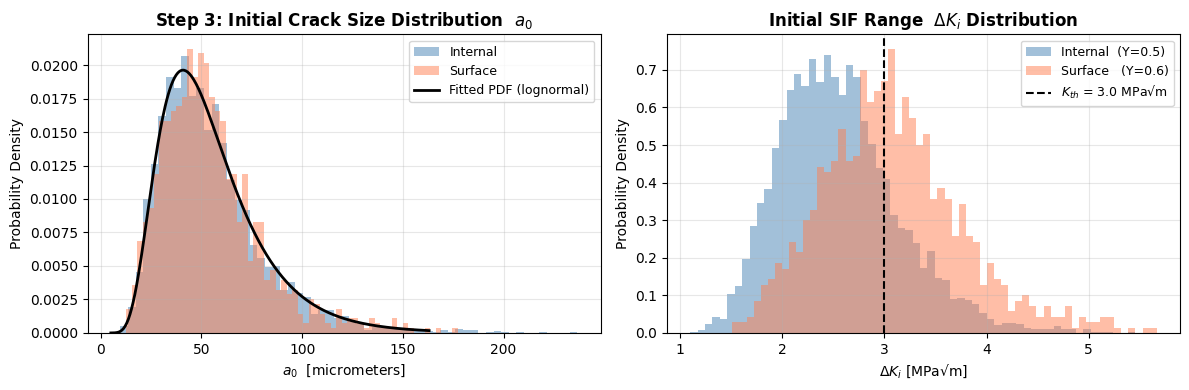

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left-side plot: a0 histogram with fitted PDF overlay ---
ax = axes[0]
a0_um = a0_arr * 1e6

ax.hist(a0_um[loc_arr == "internal"], bins=60, density=True,
        alpha=0.5, color="steelblue", label="Internal")
ax.hist(a0_um[loc_arr == "surface"], bins=60, density=True,
        alpha=0.5, color="coral", label="Surface")

x_plot = np.linspace(a_min * 1e6, np.percentile(a0_um, 99.5), 400)
pdf_plot = best_pdf.pdf(x_plot * 1e-6) / 1e6   # Jacobian m → micrometers
ax.plot(x_plot, pdf_plot, "k-", linewidth=2,
        label=f"Fitted PDF ({pdf_name})")

# title, axes labels
ax.set_title("Step 3: Initial Crack Size Distribution  $a_0$",
             fontweight="bold")
ax.set_xlabel("$a_0$  [micrometers]")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# right-side plot: initial deltaK_i distribution
ax = axes[1]
dKi_arr = Y_arr * delta_sigma * np.sqrt(np.pi * a0_arr)   # [MPa√m]

ax.hist(dKi_arr[loc_arr == "internal"], bins=60, density=True,
        alpha=0.5, color="steelblue", label="Internal  (Y=0.5)")
ax.hist(dKi_arr[loc_arr == "surface"], bins=60, density=True,
        alpha=0.5, color="coral", label="Surface   (Y=0.6)")

# Mark K_th; samples below this threshold will not grow
ax.axvline(K_th, color="black", linewidth=1.5, linestyle="--",
           label=f"$K_{{th}}$ = {K_th} MPa√m")

# axes labels, title
ax.set_title("Initial SIF Range  $\\Delta K_i$ Distribution",
             fontweight="bold")
ax.set_xlabel("$\\Delta K_i$ [MPa√m]")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/3_a0_samples.png", dpi=150)
plt.show()

## 3.5 Threshold Filter
Samples with deltaK_i < K_th will never grow under the applied loading, so they are flagged to be skipped in Step 4 (infinite life) rather than integrated a false crack-growth curve.

In [29]:
below_threshold = dKi_arr < K_th
n_below = below_threshold.sum()

print(f"Samples below K_th ({K_th} MPa√m): {n_below} / {M} "
      f"({100*n_below/M:.1f}%)  → assigned infinite life")

# apply threshold mask: keep only growing cracks for Step 4
a0_active  = a0_arr[~below_threshold]
Y_active   = Y_arr[~below_threshold]
loc_active = loc_arr[~below_threshold]
dKi_active = dKi_arr[~below_threshold]

print(f"Active samples for Step 4: {len(a0_active)}")

Samples below K_th (3.0 MPa√m): 3674 / 5000 (73.5%)  → assigned infinite life
Active samples for Step 4: 1326


## 3.6 Step 3 Output, Ready for Step 4
Everything Step 4 needs is in three parallel arrays (active samples only):
- a0_active   [m]       — initial crack sizes
- Y_active    [–]       — geometry correction factors
- dKi_active  [MPa√m]   — initial SIF ranges

In [30]:
print("\n Step 3 Output:")
print(f"  a0_active: shape {a0_active.shape}, "
      f"range [{a0_active.min()*1e6:.1f}, {a0_active.max()*1e6:.1f}] micrometers")
print(f"  Y_active: unique values {np.unique(Y_active)}")
print(f"  dKi_active: range [{dKi_active.min():.3f}, {dKi_active.max():.3f}] MPa√m")


 Step 3 Output:
  a0_active: shape (1326,), range [49.8, 236.6] micrometers
  Y_active: unique values [0.5 0.6]
  dKi_active: range [3.001, 5.664] MPa√m
